In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [1]:
from google.colab import files
uploaded=files.upload()

Saving human_cognitive_performance.csv to human_cognitive_performance.csv


In [3]:
df = pd.read_csv("human_cognitive_performance.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(80000, 13)

First 5 Rows:
  User_ID  Age  Gender  Sleep_Duration  Stress_Level       Diet_Type  \
0      U1   57  Female             6.5             3  Non-Vegetarian   
1      U2   39  Female             7.6             9  Non-Vegetarian   
2      U3   26    Male             8.2             6      Vegetarian   
3      U4   32    Male             7.8             9      Vegetarian   
4      U5   50    Male             9.7             2  Non-Vegetarian   

   Daily_Screen_Time Exercise_Frequency  Caffeine_Intake  Reaction_Time  \
0                6.5             Medium               41         583.33   
1               10.8               High              214         368.24   
2                5.7                Low              429         445.21   
3                8.3                Low              464         286.33   
4               11.3             Medium              365         237.65   

   Memory_Test_Score  Cognitive_Score  AI_Predicted_Score  
0             

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
User_ID               0
Age                   0
Gender                0
Sleep_Duration        0
Stress_Level          0
Diet_Type             0
Daily_Screen_Time     0
Exercise_Frequency    0
Caffeine_Intake       0
Reaction_Time         0
Memory_Test_Score     0
Cognitive_Score       0
AI_Predicted_Score    0
dtype: int64


In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3200/1842323058.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3200/1842323058.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [6]:
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)



Dataset Shape After Cleaning:
(80000, 13)


In [7]:
print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  object 
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  object 
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  object 
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  object 
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 7.9+ MB
None

Statistical Summary:
                Age  Sleep_Duration  Stress_L

In [10]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [11]:
if 'User_ID' in df.columns:
    df = df.drop('User_ID', axis=1)

In [12]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

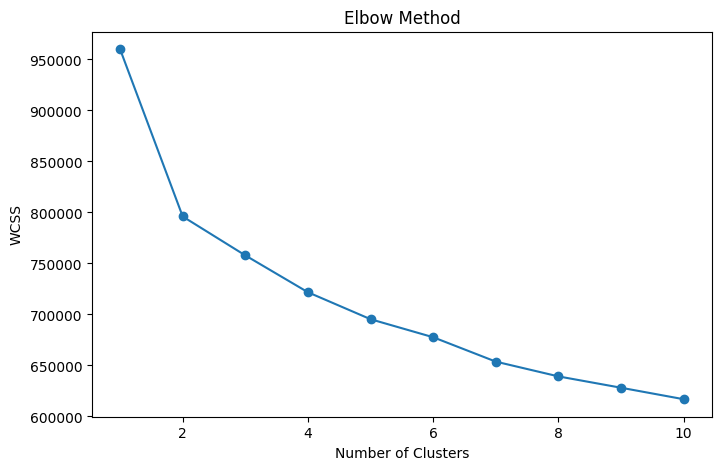

In [13]:

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


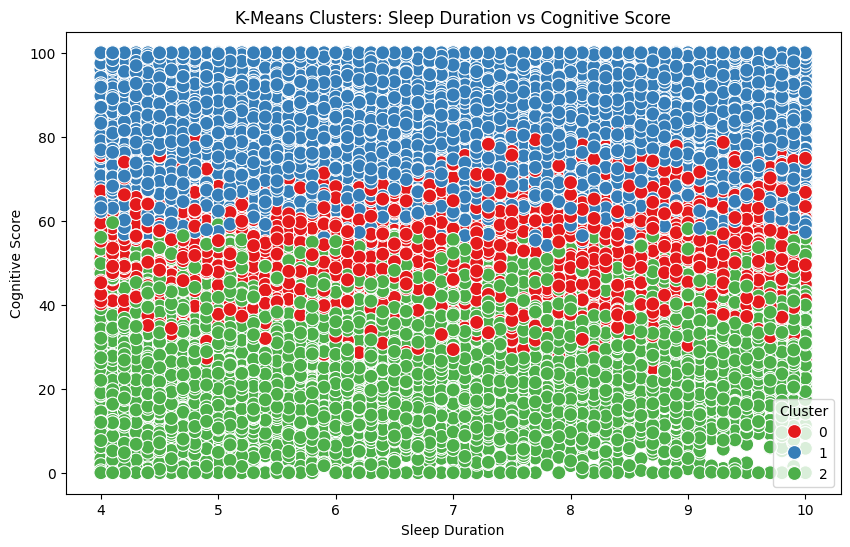

In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sleep_Duration',
    y='Cognitive_Score',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("K-Means Clusters: Sleep Duration vs Cognitive Score")
plt.xlabel("Sleep Duration")
plt.ylabel("Cognitive Score")
plt.legend(title="Cluster")
plt.show()

In [16]:
score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", round(score,4))


Silhouette Score: 0.0907


In [17]:
print("\nCluster Counts:")
print(df["Cluster"].value_counts())



Cluster Counts:
Cluster
1    33086
2    24290
0    22624
Name: count, dtype: int64


In [18]:
df.to_csv(
    "clustered_human_cognitive_performance.csv",
    index=False
)

print("\nClustered Dataset Saved Successfully")


Clustered Dataset Saved Successfully


In [19]:
from sklearn.metrics import accuracy_score
from scipy.stats import mode
import numpy as np

# Example: Use AI_Predicted_Score as true labels
y_true = df['AI_Predicted_Score']

# Convert score into 3 categories
y_true = pd.qcut(y_true, q=3, labels=[0,1,2])

# Map clusters to labels
labels = np.zeros_like(clusters)

for i in range(3):
    mask = (clusters == i)
    labels[mask] = mode(y_true[mask], keepdims=True)[0]

# Accuracy
accuracy = accuracy_score(y_true, labels)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 75.91 %
